## Decision Tree CART

CART = Classification and Regression Tree, and for classification problem, criterion="gini" uses the Gini impurity criterion.

CART = Classification and Regression Tree, and for regression problem, criterion="squared_error" uses the squared_error impurity criterion.

### Import required libraries

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

### Load Input

In [2]:
# Read weather.csv
df = pd.read_csv("weather.csv")

print(df.head())
print(df.columns)

    Outlook Temperature Humidity  Windy Play
0     Sunny         Hot     High  False   No
1     Sunny         Hot     High   True   No
2  Overcast         Hot     High  False  Yes
3      Rain        Mild     High  False  Yes
4      Rain        Cool   Normal  False  Yes
Index(['Outlook', 'Temperature', 'Humidity', 'Windy', 'Play'], dtype='object')


### # Encode categorical columns


In [3]:
# Create encoders
encoders = {}

# Encode categorical columns
for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    encoders[column] = le

### # Separate input and output

In [4]:
X_features = df.drop("Play", axis=1)
y_target = df["Play"]

### # Split the dataset


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y_target,
    test_size=0.2,
    random_state=42
)

### # Build CART Decision Tree

* criterion="gini" → uses Gini impurity, the standard CART criterion for classification.
* fit() → builds the decision tree.
* predict() → predicts the class for new data.

In [6]:
model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

### # Train the model

In [7]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### Prediction

In [8]:
y_pred = model.predict(X_test)

### Accuracy


In [9]:
print("Predicted:", y_pred)
print("Actual:", y_test.values)
print("Accuracy:", accuracy_score(y_test, y_pred))

Predicted: [1 1 0]
Actual: [1 1 0]
Accuracy: 1.0


### Visualize the CART tree

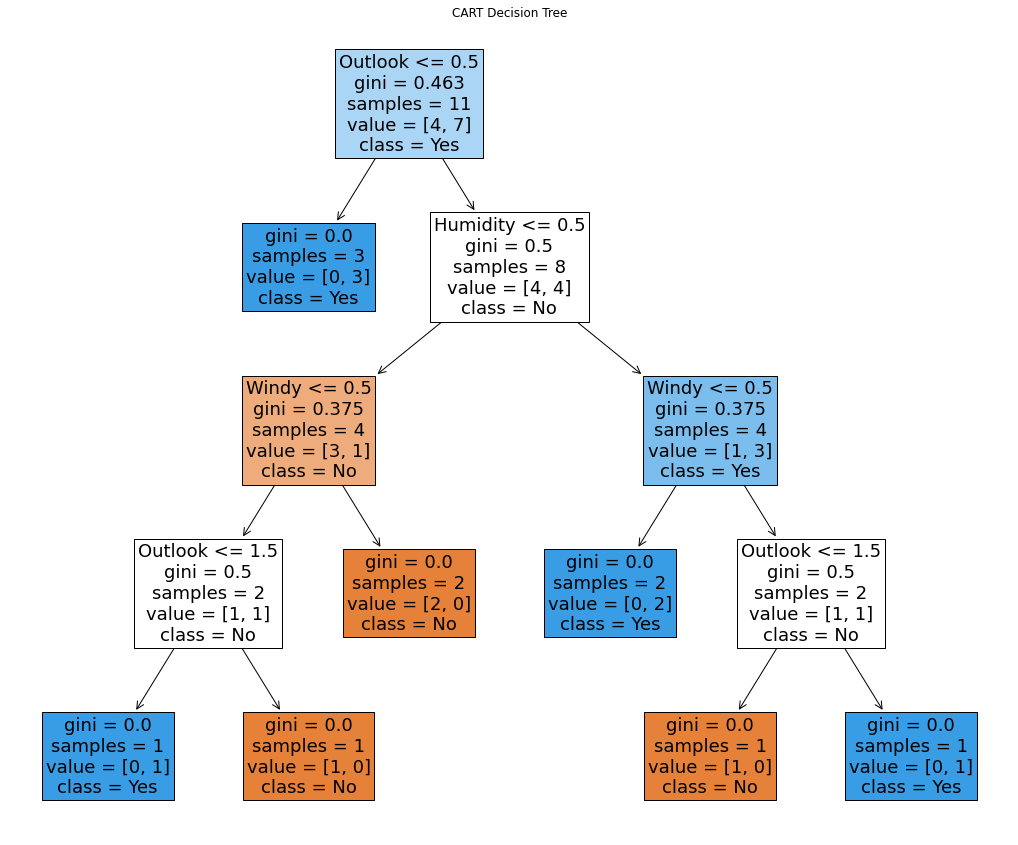

In [10]:
plt.figure(figsize=(18, 15))

plot_tree(
    model,
    feature_names=X_features.columns,
    class_names=encoders["Play"].classes_,
    filled=True,
    fontsize=18
)

plt.title("CART Decision Tree")
plt.show()

### Make prediction for new data

In [11]:
new_data = pd.DataFrame([{
    "Outlook": "Sunny",
    "Temperature": "Cool",
    "Humidity": "High",
    "Windy": False
}])

### Encode the new data
**# Convert False/True to the same format as training data**

In [12]:
new_data["Windy"] = new_data["Windy"].astype(str)

**# Encode new data using the SAME encoders**

In [13]:
# Encode new data using existing encoders
for column in X_features.columns:
    new_data[column] = encoders[column].transform(new_data[column])

In [14]:
# Predict
prediction = model.predict(new_data)

In [15]:
# Convert encoded prediction back to Yes/No
prediction_label = encoders["Play"].inverse_transform(prediction)
print("\nNew Data Prediction:", prediction_label[0])


New Data Prediction: No
